# MPC Szobahőmérséklet Szabályozó – Nappal/Éjszaka Termosztát


In [17]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [18]:
# ── 1. Szimulációs paraméterek ───────────────────────────────────────────────
dt = 1.0                
simulation_steps = 1440 
N = 30                  # 30 perc előretekintés tökéletes lesz

In [19]:
# ── 2. Termikus modell paraméterei (LASSÚ, REALISZTIKUS RENDSZER) ────────────
a = 0.01               # Kiváló hőszigetelés (lassan hűl ki)
b = 0.04               # Reális fűtés: u=100 esetén max 0.2 °C emelkedés percenként
T0 = 15.0               # kezdeti hőmérséklet

In [20]:
# ── 3. Dinamikus Zavarás Profilok Létrehozása ────────────────────────────────
# A tömböket simulation_steps + N méretűre csináljuk, 
# hogy az MPC a legutolsó lépésnél is előre tudjon tekinteni N lépést!
t_axis = np.arange(simulation_steps + N)

# Külső hőmérséklet profil: éjszaka hidegebb, nappal melegebb (szinuszos hullám)
T_out_profile = 7.0 + 5.0 * np.sin(2 * np.pi * t_axis / 1440 - np.pi / 2)

# Belső hőterhelés (pl. besüt a nap vagy emberek vannak a szobában)
Q_dist_profile = np.zeros(simulation_steps + N)
Q_dist_profile[600:900] = 0.06  # 10:00 és 15:00 között extra hőtermelés

In [21]:
# ── 4. Referencia ütemterv (Nappal/Éjszaka) ──────────────────────────────────
def get_reference(t):
    """Visszaadja az aktuális célhőmérsékletet az időlépés alapján."""
    day_time = t % 1440
    if 480 <= day_time < 1320:  # 08:00-tól 22:00-ig
        return 22.0             # Nappal: 22 °C
    else:                       
        return 18.0             # Éjszaka: 18 °C

In [22]:
# ── 5. MPC Vezérlő Függvény ──────────────────────────────────────────────────
def mpc_controller(current_temp, t_current):
    """
    MPC optimalizáció az aktuális hőmérséklettől és időlépéstől indulva.
    A horizonton belül figyelembe veszi a jövőbeli zavarásokat is!
    """
    u = cp.Variable(N)
    T = cp.Variable(N + 1)

    constraints = [T[0] == current_temp]
    cost = 0

    for k in range(N):
        future_idx = t_current + k
        T_ref_k = get_reference(future_idx)
        
        T_out_future = T_out_profile[future_idx]
        Q_dist_future = Q_dist_profile[future_idx]

        # Rendszerdinamika beépített dinamikus zavarásokkal
        constraints += [
            T[k + 1] == T[k] + dt * (
                -a * (T[k] - T_out_future) + b * u[k] + Q_dist_future
            )
        ]

        # Beavatkozó jel korlátok
        constraints += [
            u[k] >= 0,
            u[k] <= 100
        ]

        # KÖLTSÉGFÜGGVÉNY: Hőmérséklet követés büntetése
        cost += cp.square(T[k] - T_ref_k)
        
        # A varázslat: a fűtés hirtelen változásának (slew rate) büntetése!
        if k > 0:
            cost += 0.5 * cp.square(u[k] - u[k-1])

    problem = cp.Problem(cp.Minimize(cost), constraints)
    problem.solve()

    return u.value[0]

In [23]:
# ── 6. Szimulációs Ciklus ────────────────────────────────────────────────────
print("Szimuláció indítása, ez eltarthat egy-két percig...")

temperature = T0
temperature_history = []
control_history = []
reference_history = []
time_history = []

for t in range(simulation_steps):
    T_ref = get_reference(t)

    # 1. MPC kiszámítja az optimális fűtést
    control = mpc_controller(temperature, t)

    # 2. A valós rendszer frissítése az aktuális fűtéssel és zavarásokkal
    temperature = temperature + dt * (
        -a * (temperature - T_out_profile[t]) + b * control + Q_dist_profile[t]
    )

    # 3. Adatok mentése a grafikonokhoz
    temperature_history.append(temperature)
    control_history.append(control)
    reference_history.append(T_ref)
    time_history.append(t)
    
    if t % 200 == 0 and t > 0:
        print(f"[{t}/{simulation_steps}] lépés kész...")

print("Szimuláció kész!")

Szimuláció indítása, ez eltarthat egy-két percig...
[200/1440] lépés kész...
[400/1440] lépés kész...
[600/1440] lépés kész...
[800/1440] lépés kész...
[1000/1440] lépés kész...
[1200/1440] lépés kész...
[1400/1440] lépés kész...
Szimuláció kész!


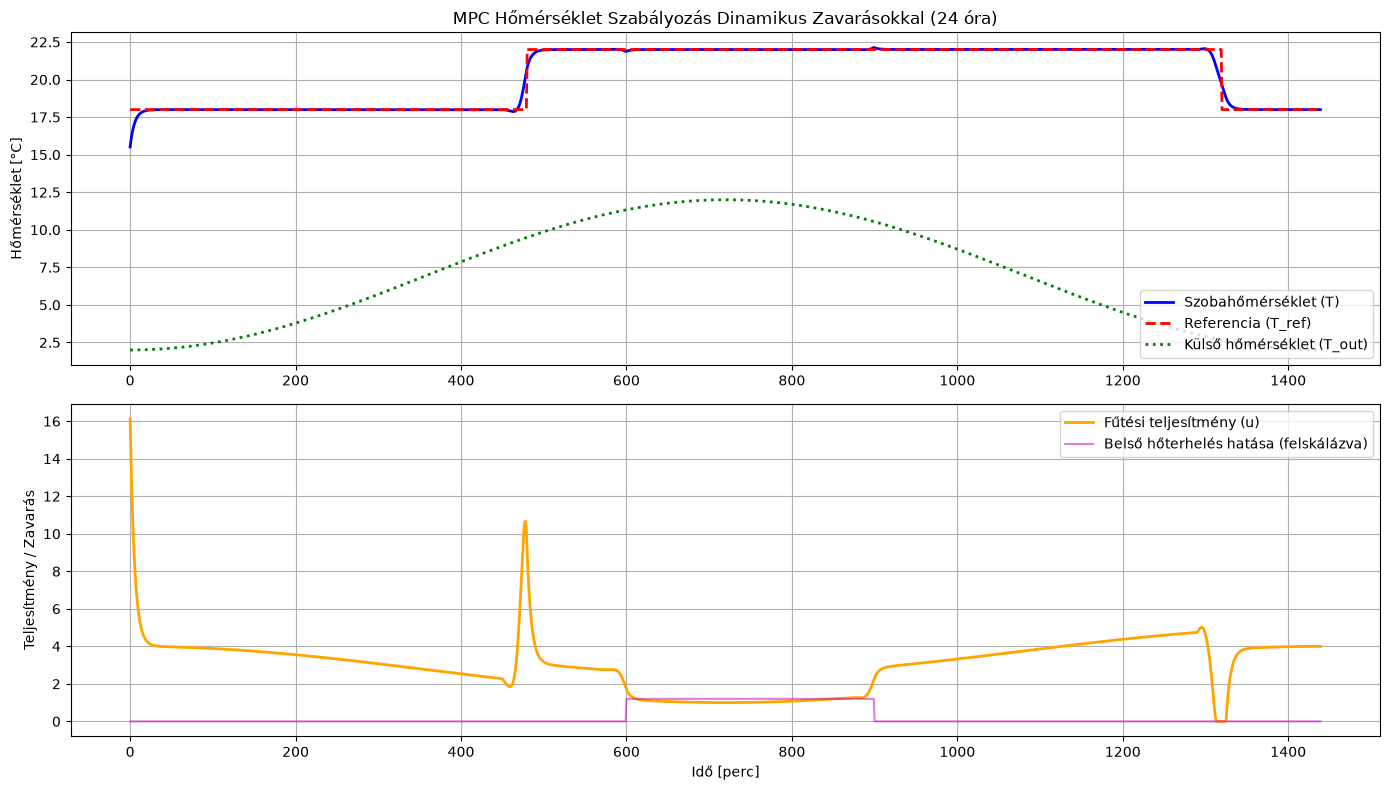

In [24]:
# ── 7. Eredmények Vizualizációja ─────────────────────────────────────────────
plt.figure(figsize=(14, 8))

# Első grafikon: Hőmérsékletek alakulása
plt.subplot(2, 1, 1)
plt.plot(time_history, temperature_history, label='Szobahőmérséklet (T)', color='blue', linewidth=2)
plt.plot(time_history, reference_history, 'r--', label='Referencia (T_ref)', linewidth=2)
plt.plot(time_history, T_out_profile[:simulation_steps], 'g:', label='Külső hőmérséklet (T_out)', linewidth=2)
plt.title('MPC Hőmérséklet Szabályozás Dinamikus Zavarásokkal (24 óra)')
plt.ylabel('Hőmérséklet [°C]')
plt.grid(True)
plt.legend(loc='lower right')

# Második grafikon: Fűtési teljesítmény és belső hőterhelés
plt.subplot(2, 1, 2)
plt.plot(time_history, control_history, label='Fűtési teljesítmény (u)', color='orange', linewidth=2)
# A hőterhelést felskálázzuk a vizuális ábrázolhatóság kedvéért
plt.plot(time_history, Q_dist_profile[:simulation_steps] * 20, 'm-', alpha=0.5, label='Belső hőterhelés hatása (felskálázva)')
plt.xlabel('Idő [perc]')
plt.ylabel('Teljesítmény / Zavarás')
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()